# CVAE-H on Fashion-MNIST (quadrant inpainting)

**Task:** Each $28\times28$ image is split into four $14\times14$ quadrants. One, two, or three quadrants are given as input; the model predicts the full image, and training minimizes reconstruction (Bernoulli / BCE) on the **missing** quadrants only.

- **Condition** $C$: Fashion-MNIST label (10-d one-hot) + 4 binary flags (which quadrants are observed).
- **Encoder input:** concatenated `x \odot m` and pixel mask $m$ (so zeros are not ambiguous).
- **Loss:** standard ELBO: masked BCE + $\beta_t\,$KL with linear **KL annealing**; **fixed epoch** count (no early stopping).

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms as T
import matplotlib.pyplot as plt
import numpy as np
import random
import time

## Hyperparameters

In [2]:
LATENT_DIM   = 16
NUM_CLASSES  = 10
QUAD_BITS    = 4
COND_DIM     = NUM_CLASSES + QUAD_BITS

OUT_DIM      = 784
ENC_IN       = 2 * OUT_DIM

ENC_H1, ENC_H2 = 256, 128
DEC_H1, DEC_H2 = 128, 256

HYPER_HIDDEN = 256

BATCH_SIZE   = 128
NUM_EPOCHS   = 50
LR           = 3e-4

KL_WEIGHT    = 1.0
KL_ANNEAL_EPOCHS = 30

RNG_SEED = 42
random.seed(RNG_SEED)
np.random.seed(RNG_SEED)
torch.manual_seed(RNG_SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {DEVICE}")
print("=" * 60)
print("CVAE-H | Fashion-MNIST | quadrant inpainting")
print("=" * 60)

Device: cpu
CVAE-H | Fashion-MNIST | quadrant inpainting


## Quadrant masks

Flat index order is row-major: `i = r * 28 + c`. Quadrants: TL=0, TR=1, BL=2, BR=3.

In [3]:
def build_quadrant_pixel_masks(device=None):
    masks = []
    for q in range(4):
        m = torch.zeros(28, 28, device=device)
        if q == 0:
            m[:14, :14] = 1
        elif q == 1:
            m[:14, 14:] = 1
        elif q == 2:
            m[14:, :14] = 1
        else:
            m[14:, 14:] = 1
        masks.append(m.reshape(-1))
    return torch.stack(masks, dim=0)


QUAD_PIXEL = build_quadrant_pixel_masks()


def valid_quad_bit_patterns():
    rows = []
    for bits in range(1, 16):
        if sum((bits >> k) & 1 for k in range(4)) not in (1, 2, 3):
            continue
        v = [(bits >> k) & 1 for k in range(4)]
        rows.append(v)
    return torch.tensor(rows, dtype=torch.float32)


QUAD_PATTERN_BANK = valid_quad_bit_patterns()


def sample_quadrant_pattern(batch_size, device):
    idx = torch.randint(0, QUAD_PATTERN_BANK.size(0), (batch_size,), device=device)
    qbits = QUAD_PATTERN_BANK.to(device)[idx]
    return qbits, idx


def pixel_obs_mask_from_quads(qbits, device):
    m = torch.zeros(qbits.size(0), OUT_DIM, device=device)
    for q in range(4):
        m += qbits[:, q : q + 1] * QUAD_PIXEL[q].to(device)
    m = (m > 0).float()
    return m


def condition_vector(labels, qbits, num_classes=NUM_CLASSES):
    oh = F.one_hot(labels, num_classes=num_classes).float()
    return torch.cat([oh, qbits], dim=1)

## Load Fashion-MNIST

In [4]:
tfm = T.Compose([T.ToTensor()])
train_set = torchvision.datasets.FashionMNIST(
    root="./data", train=True, download=True, transform=tfm
)
test_set = torchvision.datasets.FashionMNIST(
    root="./data", train=False, download=True, transform=tfm
)

train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
test_loader = DataLoader(test_set, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"Train: {len(train_set):,}  Test: {len(test_set):,}  Batches/epoch: {len(train_loader)}")

Train: 60,000  Test: 10,000  Batches/epoch: 469


## HyperNetwork, Encoder, Decoder, CVAE-H

In [5]:
class HyperNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.backbone = nn.Sequential(
            nn.Linear(COND_DIM, HYPER_HIDDEN),
            nn.ReLU(),
            nn.Linear(HYPER_HIDDEN, HYPER_HIDDEN),
            nn.ReLU(),
        )
        self.enc1_scale = nn.Linear(HYPER_HIDDEN, ENC_H1)
        self.enc1_bias = nn.Linear(HYPER_HIDDEN, ENC_H1)
        self.enc2_scale = nn.Linear(HYPER_HIDDEN, ENC_H2)
        self.enc2_bias = nn.Linear(HYPER_HIDDEN, ENC_H2)
        self.mu_scale = nn.Linear(HYPER_HIDDEN, LATENT_DIM)
        self.mu_bias = nn.Linear(HYPER_HIDDEN, LATENT_DIM)
        self.lv_scale = nn.Linear(HYPER_HIDDEN, LATENT_DIM)
        self.lv_bias = nn.Linear(HYPER_HIDDEN, LATENT_DIM)

        self.dec1_scale = nn.Linear(HYPER_HIDDEN, DEC_H1)
        self.dec1_bias = nn.Linear(HYPER_HIDDEN, DEC_H1)
        self.dec2_scale = nn.Linear(HYPER_HIDDEN, DEC_H2)
        self.dec2_bias = nn.Linear(HYPER_HIDDEN, DEC_H2)
        self.out_scale = nn.Linear(HYPER_HIDDEN, OUT_DIM)
        self.out_bias = nn.Linear(HYPER_HIDDEN, OUT_DIM)

    def forward(self, c):
        h = self.backbone(c)
        return {
            "enc1": (self.enc1_scale(h), self.enc1_bias(h)),
            "enc2": (self.enc2_scale(h), self.enc2_bias(h)),
            "mu": (self.mu_scale(h), self.mu_bias(h)),
            "lv": (self.lv_scale(h), self.lv_bias(h)),
            "dec1": (self.dec1_scale(h), self.dec1_bias(h)),
            "dec2": (self.dec2_scale(h), self.dec2_bias(h)),
            "out": (self.out_scale(h), self.out_bias(h)),
        }

In [6]:
class HyperEncoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(ENC_IN, ENC_H1)
        self.fc2 = nn.Linear(ENC_H1, ENC_H2)
        self.fc_mu = nn.Linear(ENC_H2, LATENT_DIM)
        self.fc_logvar = nn.Linear(ENC_H2, LATENT_DIM)

    def forward(self, x_enc, hp):
        s1, b1 = hp["enc1"]
        s2, b2 = hp["enc2"]
        sm, bm = hp["mu"]
        sl, bl = hp["lv"]
        h = F.relu(self.fc1(x_enc) * s1 + b1)
        h = F.relu(self.fc2(h) * s2 + b2)
        mu = self.fc_mu(h) * sm + bm
        logvar = self.fc_logvar(h) * sl + bl
        return mu, logvar


class HyperDecoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(LATENT_DIM, DEC_H1)
        self.fc2 = nn.Linear(DEC_H1, DEC_H2)
        self.fc3 = nn.Linear(DEC_H2, OUT_DIM)

    def forward(self, z, hp):
        s1, b1 = hp["dec1"]
        s2, b2 = hp["dec2"]
        so, bo = hp["out"]
        h = F.relu(self.fc1(z) * s1 + b1)
        h = F.relu(self.fc2(h) * s2 + b2)
        x_hat = torch.sigmoid(self.fc3(h) * so + bo)
        return x_hat

In [7]:
class CVAEH(nn.Module):
    def __init__(self):
        super().__init__()
        self.hypernetwork = HyperNetwork()
        self.encoder = HyperEncoder()
        self.decoder = HyperDecoder()

    @staticmethod
    def reparameterise(mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x_enc, c_onehot):
        hp = self.hypernetwork(c_onehot)
        mu, logvar = self.encoder(x_enc, hp)
        z = self.reparameterise(mu, logvar)
        x_hat = self.decoder(z, hp)
        return x_hat, mu, logvar

    @torch.no_grad()
    def generate_inpaint(self, x_enc, c_onehot):
        hp = self.hypernetwork(c_onehot)
        mu, logvar = self.encoder(x_enc, hp)
        z = self.reparameterise(mu, logvar)
        return self.decoder(z, hp)

## ELBO (masked reconstruction + standard KL)

In [8]:
def masked_bce_reconstruction(x_hat, x, obs_mask):
    pred_mask = 1.0 - obs_mask
    bce = F.binary_cross_entropy(x_hat, x, reduction="none")
    denom = pred_mask.sum(dim=1).clamp(min=1.0)
    per_sample = (bce * pred_mask).sum(dim=1) / denom
    return per_sample.mean()


def elbo_loss(x, x_hat, mu, logvar, obs_mask, kl_weight):
    recon = masked_bce_reconstruction(x_hat, x, obs_mask)
    kl = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp()) / x.size(0)
    total = recon + kl_weight * kl
    return total, recon, kl


def kl_anneal_beta(epoch):
    if KL_ANNEAL_EPOCHS <= 0:
        return KL_WEIGHT
    t = min(1.0, (epoch + 1) / float(KL_ANNEAL_EPOCHS))
    return KL_WEIGHT * t

## Model & training (fixed `NUM_EPOCHS`)

In [9]:
model = CVAEH().to(DEVICE)
optimiser = torch.optim.Adam(model.parameters(), lr=LR)

n_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {n_params:,}")

Total parameters: 1,559,184


In [10]:
def prepare_batch(imgs, labels, device):
    x = imgs.view(imgs.size(0), -1).to(device)
    y = labels.to(device)
    qbits, _ = sample_quadrant_pattern(x.size(0), device)
    obs = pixel_obs_mask_from_quads(qbits, device)
    x_enc = torch.cat([x * obs, obs], dim=1)
    c = condition_vector(y, qbits)
    return x, x_enc, c, obs


def run_epoch(loader, train=True, beta_kl=1.0):
    if train:
        model.train()
    else:
        model.eval()
    tot_loss = tot_recon = tot_kl = 0.0
    n_batches = 0
    for imgs, labels in loader:
        x, x_enc, c, obs = prepare_batch(imgs, labels, DEVICE)
        if train:
            optimiser.zero_grad(set_to_none=True)
            x_hat, mu, logvar = model(x_enc, c)
            loss, recon, kl = elbo_loss(x, x_hat, mu, logvar, obs, beta_kl)
            loss.backward()
            optimiser.step()
        else:
            with torch.no_grad():
                x_hat, mu, logvar = model(x_enc, c)
                loss, recon, kl = elbo_loss(x, x_hat, mu, logvar, obs, beta_kl)
        tot_loss += loss.item()
        tot_recon += recon.item()
        tot_kl += kl.item()
        n_batches += 1
    return tot_loss / n_batches, tot_recon / n_batches, tot_kl / n_batches


history = {"train_loss": [], "train_recon": [], "train_kl": [], "val_loss": [], "val_recon": [], "val_kl": []}

for epoch in range(NUM_EPOCHS):
    t0 = time.time()
    beta = kl_anneal_beta(epoch)
    tr = run_epoch(train_loader, train=True, beta_kl=beta)
    va = run_epoch(test_loader, train=False, beta_kl=beta)
    history["train_loss"].append(tr[0])
    history["train_recon"].append(tr[1])
    history["train_kl"].append(tr[2])
    history["val_loss"].append(va[0])
    history["val_recon"].append(va[1])
    history["val_kl"].append(va[2])
    dt = time.time() - t0
    print(
        f"Epoch {epoch+1:3d}/{NUM_EPOCHS} ({dt:.1f}s)  β={beta:.4f} | "
        f"train L={tr[0]:.4f} recon={tr[1]:.4f} kl={tr[2]:.4f} | "
        f"val L={va[0]:.4f} recon={va[1]:.4f} kl={va[2]:.4f}"
    )

print("Training finished (fixed epoch budget; no early stopping).")

Epoch   1/50 (33.4s)  β=0.0333 | train L=0.4270 recon=0.4269 kl=0.0027 | val L=0.3955 recon=0.3955 kl=0.0008
Epoch   2/50 (44.2s)  β=0.0667 | train L=0.3933 recon=0.3933 kl=0.0003 | val L=0.3934 recon=0.3934 kl=0.0002
Epoch   3/50 (43.8s)  β=0.1000 | train L=0.3928 recon=0.3928 kl=0.0001 | val L=0.3939 recon=0.3939 kl=0.0001
Epoch   4/50 (43.0s)  β=0.1333 | train L=0.3923 recon=0.3922 kl=0.0001 | val L=0.3920 recon=0.3920 kl=0.0001
Epoch   5/50 (42.6s)  β=0.1667 | train L=0.3924 recon=0.3924 kl=0.0001 | val L=0.3940 recon=0.3940 kl=0.0001
Epoch   6/50 (43.3s)  β=0.2000 | train L=0.3928 recon=0.3928 kl=0.0001 | val L=0.3934 recon=0.3934 kl=0.0001
Epoch   7/50 (43.0s)  β=0.2333 | train L=0.3926 recon=0.3926 kl=0.0001 | val L=0.3936 recon=0.3936 kl=0.0000
Epoch   8/50 (43.2s)  β=0.2667 | train L=0.3922 recon=0.3922 kl=0.0000 | val L=0.3944 recon=0.3944 kl=0.0000
Epoch   9/50 (42.9s)  β=0.3000 | train L=0.3925 recon=0.3925 kl=0.0000 | val L=0.3948 recon=0.3948 kl=0.0000
Epoch  10/50 (43.8s

## Curves

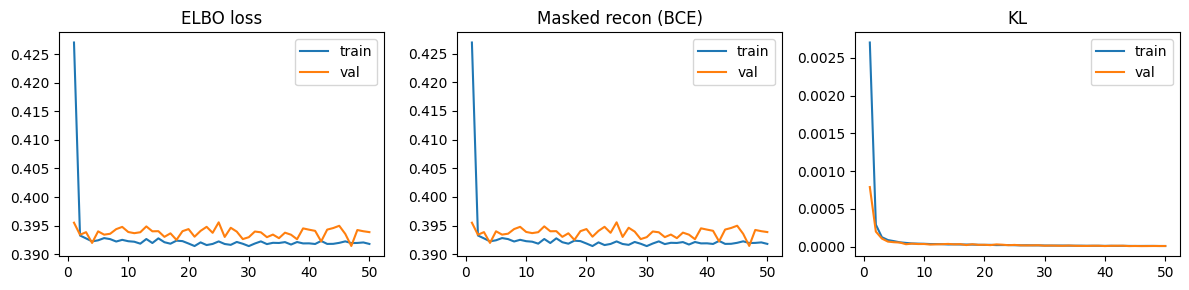

In [11]:
ep = np.arange(1, NUM_EPOCHS + 1)
fig, ax = plt.subplots(1, 3, figsize=(12, 3))
ax[0].plot(ep, history["train_loss"], label="train")
ax[0].plot(ep, history["val_loss"], label="val")
ax[0].set_title("ELBO loss")
ax[0].legend()
ax[1].plot(ep, history["train_recon"], label="train")
ax[1].plot(ep, history["val_recon"], label="val")
ax[1].set_title("Masked recon (BCE)")
ax[1].legend()
ax[2].plot(ep, history["train_kl"], label="train")
ax[2].plot(ep, history["val_kl"], label="val")
ax[2].set_title("KL")
ax[2].legend()
plt.tight_layout()
plt.show()

## Qualitative visualization (blend prediction into missing regions)

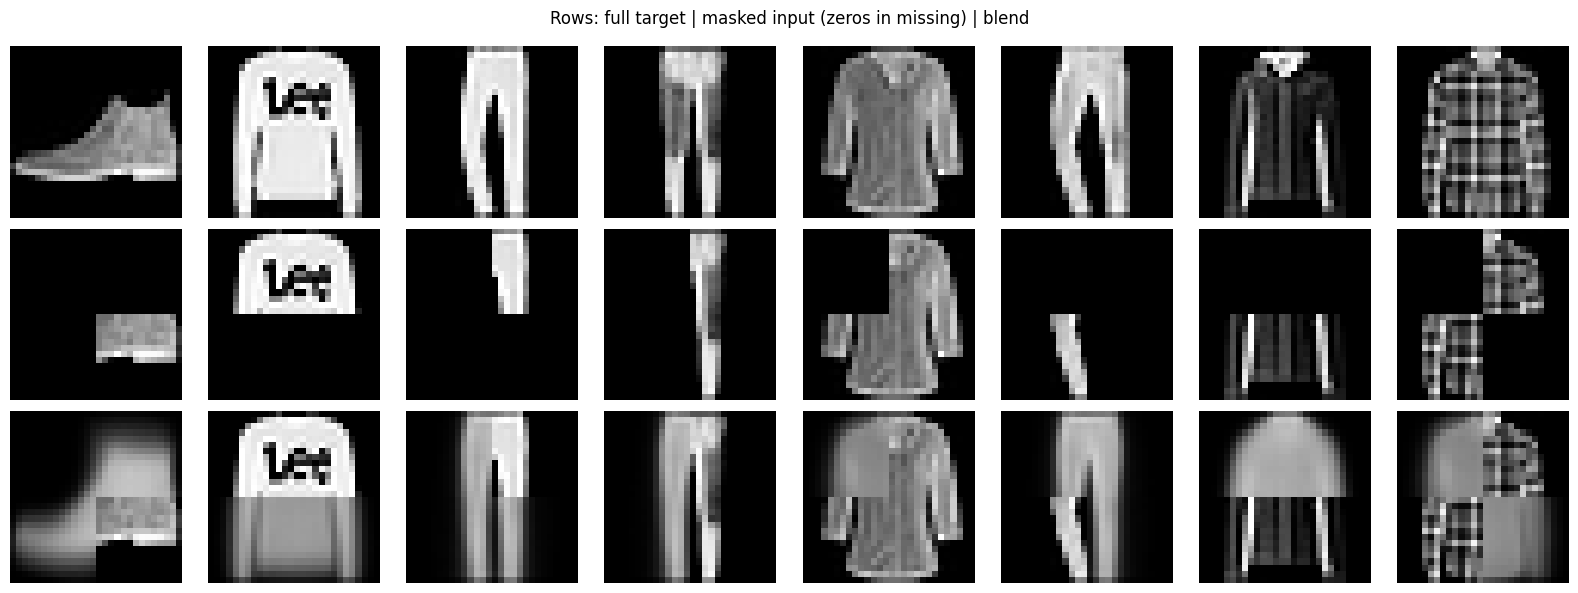

In [12]:
model.eval()


def show_inpaint_grid(num_show=8, seed=0):
    torch.manual_seed(seed)
    it = iter(test_loader)
    imgs, labels = next(it)
    imgs, labels = imgs[:num_show], labels[:num_show]
    x, x_enc, c, obs = prepare_batch(imgs, labels, DEVICE)

    with torch.no_grad():
        x_hat, _, _ = model(x_enc, c)

    comp = obs * x + (1 - obs) * x_hat

    fig, axes = plt.subplots(3, num_show, figsize=(2 * num_show, 6))
    for i in range(num_show):
        axes[0, i].imshow(x[i].view(28, 28).cpu(), cmap="gray", vmin=0, vmax=1)
        axes[0, i].axis("off")
        axes[1, i].imshow((x[i] * obs[i]).view(28, 28).cpu(), cmap="gray", vmin=0, vmax=1)
        axes[1, i].axis("off")
        axes[2, i].imshow(comp[i].view(28, 28).cpu(), cmap="gray", vmin=0, vmax=1)
        axes[2, i].axis("off")
    axes[0, 0].set_ylabel("Target", rotation=90, size=10)
    axes[1, 0].set_ylabel("Observed", rotation=90, size=10)
    axes[2, 0].set_ylabel("Obs + pred", rotation=90, size=10)
    plt.suptitle("Rows: full target | masked input (zeros in missing) | blend")
    plt.tight_layout()
    plt.show()


show_inpaint_grid()